#  MedExplain-XAI: Explainable Machine Learning for Heart Disease Risk Prediction

# Project Objective

The objective of MedExplain-XAI is to develop an interpretable machine learning framework for predicting the presence of heart disease from clinical attributes and understanding the factors that influence the model's predictions.

The project combines multiple machine learning classification techniques with Explainable Artificial Intelligence (XAI). Different classification models will be trained and compared using appropriate evaluation metrics, followed by SHAP-based analysis of the best-performing model.

The project aims to demonstrate how machine learning can be used not only to generate predictions, but also to provide interpretable insights into the factors contributing to those predictions.

# Research Questions

1. How effectively can machine learning models predict the presence of heart disease using clinical features?
2. Which classification model provides the best predictive performance?
3. Which clinical features have the greatest influence on the model's predictions?
4. Can SHAP-based Explainable AI provide meaningful interpretations of model predictions?
5. What types of observations are more difficult for the model to classify correctly?

# Dataset Description

The project uses the Heart Disease dataset from the UCI Machine Learning Repository.

The Cleveland dataset contains 303 instances and 13 predictive features related to clinical and physiological characteristics. The target variable represents the presence or absence of heart disease.

The dataset includes attributes such as age, sex, chest-pain type, resting blood pressure, cholesterol, fasting blood sugar, resting ECG results, maximum heart rate, exercise-induced angina, ST depression, slope, number of major vessels, and thalassemia-related information.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving heart+disease.zip to heart+disease.zip


# Dataset Loading

The Heart Disease dataset used in this project was obtained from the UCI Machine Learning Repository. The downloaded ZIP file contains the original Cleveland heart disease dataset along with related files.

For this study, the Cleveland dataset is selected because it contains clinical attributes that can be used to develop a binary classification model for predicting the presence or absence of heart disease.

The dataset will first be extracted from the uploaded ZIP file. After extraction, the Cleveland data file will be identified and loaded into a Pandas DataFrame for further analysis and preprocessing.

In [4]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("heart_disease")

print("Heart Disease ZIP extracted successfully!")

print("\nExtracted files:")

for root, dirs, files in os.walk("heart_disease"):
    for file in files:
        print(os.path.join(root, file))

Heart Disease ZIP extracted successfully!

Extracted files:
heart_disease/ask-detrano
heart_disease/switzerland.data
heart_disease/Index
heart_disease/reprocessed.hungarian.data
heart_disease/processed.va.data
heart_disease/cleveland.data
heart_disease/bak
heart_disease/heart-disease.names
heart_disease/new.data
heart_disease/long-beach-va.data
heart_disease/processed.switzerland.data
heart_disease/cleve.mod
heart_disease/WARNING
heart_disease/processed.hungarian.data
heart_disease/processed.cleveland.data
heart_disease/hungarian.data
heart_disease/costs/heart-disease.delay
heart_disease/costs/Index
heart_disease/costs/heart-disease.expense
heart_disease/costs/heart-disease.cost
heart_disease/costs/heart-disease.group
heart_disease/costs/heart-disease.README


# Loading the Cleveland Dataset

The extracted UCI Heart Disease dataset contains data collected from multiple sources. For this project, only the Cleveland dataset is selected to maintain a consistent and reproducible analysis.

The Cleveland dataset is stored in the `processed.cleveland.data` file. Since the original file does not contain column names, the feature names provided in the UCI dataset documentation will be assigned manually.

The dataset contains clinical and physiological attributes such as age, sex, chest-pain type, resting blood pressure, cholesterol, maximum heart rate, exercise-induced angina, and other clinical measurements. The target variable indicates the presence or absence of heart disease.

In [5]:
import pandas as pd

# Path to the Cleveland dataset
file_path = "heart_disease/processed.cleveland.data"

# Column names provided by the UCI Heart Disease dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

# Load the dataset
df = pd.read_csv(
    file_path,
    names=columns,
    na_values="?"
)

print("Cleveland Heart Disease dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Cleveland Heart Disease dataset loaded successfully!
Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Data Understanding

Before performing data preprocessing and machine learning, it is important to understand the structure and characteristics of the dataset.

The data understanding stage examines the number of observations and features, the data types of each variable, the first few records, and the presence of missing values.

This step helps identify potential data-quality issues and provides an initial understanding of the clinical variables that will be used for heart disease risk prediction.

In [6]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(303, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        

# Data Cleaning

The initial data inspection identified missing values in two clinical features: `ca` and `thal`.

The `ca` feature contains 4 missing observations, while the `thal` feature contains 2 missing observations. Since these features are important for the predictive modelling stage, the missing values need to be handled before training the machine learning models.

Instead of removing complete rows, which would reduce the already limited dataset size, missing values will be replaced using the median value of the corresponding feature. Median imputation is less sensitive to extreme values than mean imputation and helps preserve the available observations.

After imputation, the dataset will be checked again to confirm that no missing values remain.

In [7]:
# Check missing values before cleaning

print("Missing values before cleaning:")
print(df[["ca", "thal"]].isnull().sum())

# Fill missing values using median
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nData cleaning completed successfully!")

Missing values before cleaning:
ca      4
thal    2
dtype: int64

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data cleaning completed successfully!


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of the clinical variables and identify patterns within the dataset before applying machine learning algorithms.

The analysis examines the distribution of the target variable, demographic characteristics, clinical measurements, and relationships between important features.

Visualizations are used to identify patterns and differences between observations with and without heart disease. This exploratory analysis provides useful insights for selecting and preparing features for the subsequent machine learning stage.

# Target Variable Distribution

The target variable represents the presence or absence of heart disease. Examining its distribution helps determine whether the dataset is reasonably balanced between the two classes.

A balanced target distribution is useful for classification because the model receives a meaningful number of observations from both classes during training.

Target Value Counts:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


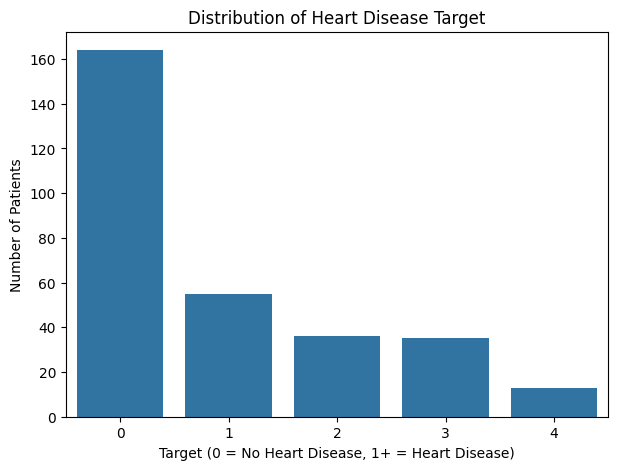

In [8]:
# Target variable distribution

print("Target Value Counts:")
print(df["target"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(x="target", data=df)

plt.title("Distribution of Heart Disease Target")
plt.xlabel("Target (0 = No Heart Disease, 1+ = Heart Disease)")
plt.ylabel("Number of Patients")

plt.show()

# Age Distribution

Age is an important demographic variable in the heart disease dataset. Examining its distribution helps us understand the age range represented in the observations.

The age distribution is visualized using a histogram with a density curve. This allows us to identify the most common age ranges and observe the overall distribution of patients included in the dataset.

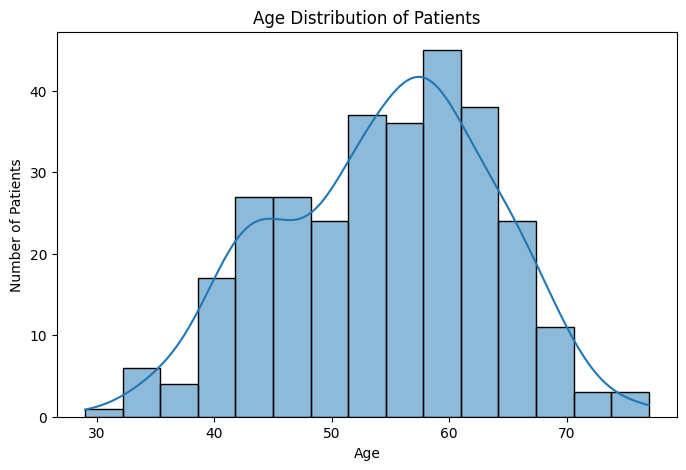

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["age"],
    bins=15,
    kde=True
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

# Sex Distribution of Patients

Sex is another important demographic variable in the dataset. This analysis examines the distribution of male and female observations.

The original dataset represents sex as a numerical variable, where 0 represents female and 1 represents male. A count plot is used to visualize the number of observations in each category.

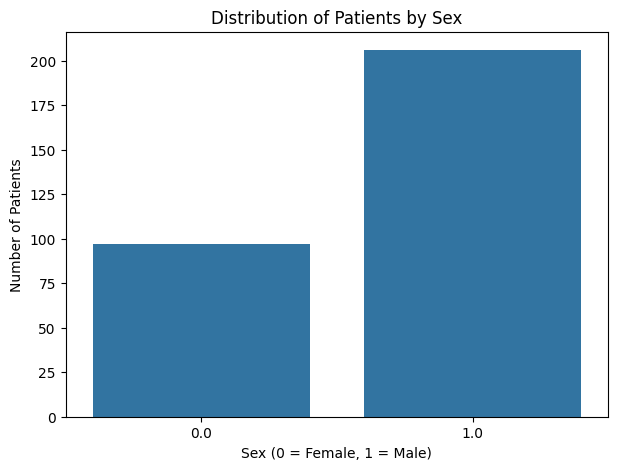

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="sex",
    data=df
)

plt.title("Distribution of Patients by Sex")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Number of Patients")

plt.show()

# Heart Disease Distribution by Sex

After examining the overall sex distribution, the relationship between sex and the original heart disease target is analyzed.

A grouped count plot is used to compare the number of observations across the different heart disease target categories for male and female patients. This helps provide an initial understanding of how the target categories are distributed across the two sex groups.

This visualization is exploratory and does not by itself establish a causal relationship between sex and heart disease.

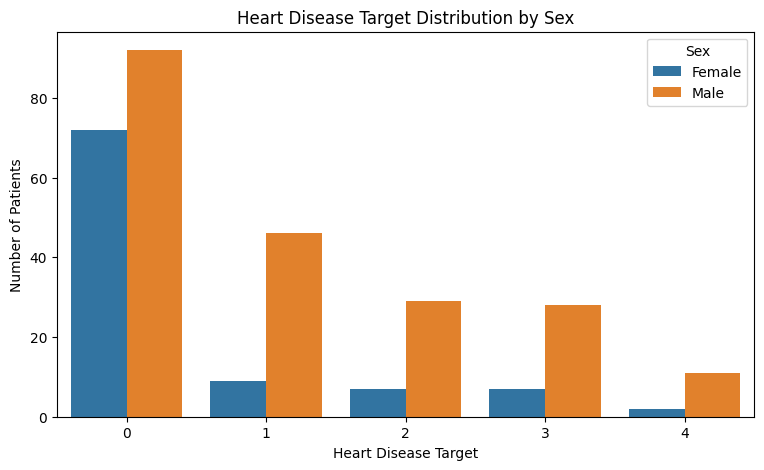

In [11]:
plt.figure(figsize=(9, 5))

sns.countplot(
    x="target",
    hue="sex",
    data=df
)

plt.title("Heart Disease Target Distribution by Sex")
plt.xlabel("Heart Disease Target")
plt.ylabel("Number of Patients")
plt.legend(
    title="Sex",
    labels=["Female", "Male"]
)

plt.show()

#Feature Correlation Analysis

Correlation analysis is performed to examine the relationships between the numerical variables in the dataset.

A correlation matrix is visualized using a heatmap. Positive correlation indicates that two variables tend to increase together, while negative correlation indicates that one variable tends to decrease as the other increases.

The correlation analysis provides an exploratory view of relationships among the clinical features and helps identify potentially related variables before developing the machine learning models.

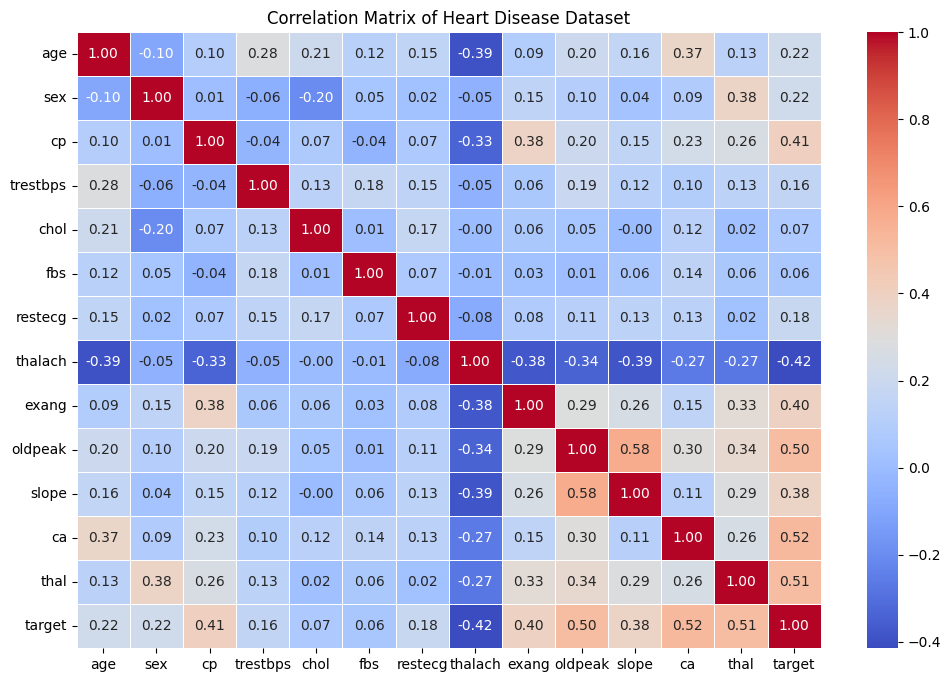

In [12]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Heart Disease Dataset")

plt.show()

#Distribution of Clinical Features

The distributions of selected clinical measurements are examined to understand their ranges and variability within the dataset.

Age, resting blood pressure, cholesterol, and maximum heart rate are visualized using histograms. These variables represent important demographic and physiological characteristics that will later be used by the machine learning models.

Understanding their distributions helps identify the typical ranges of the observations and provides additional insight into the dataset before model development.

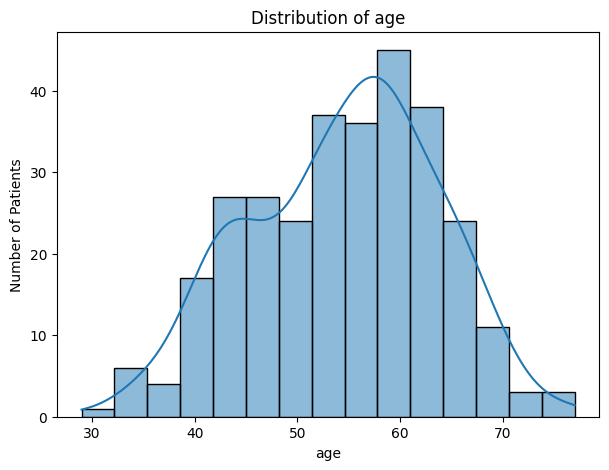

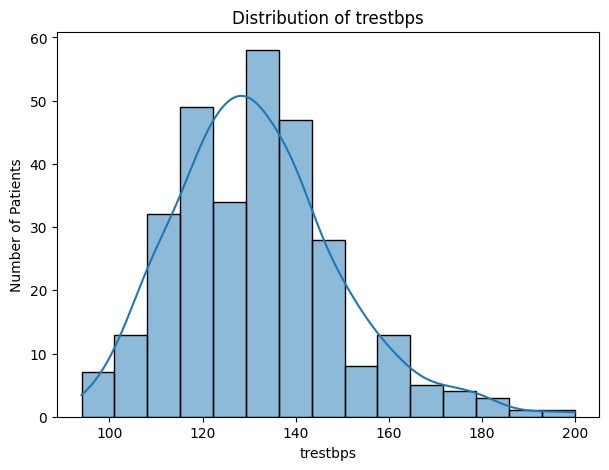

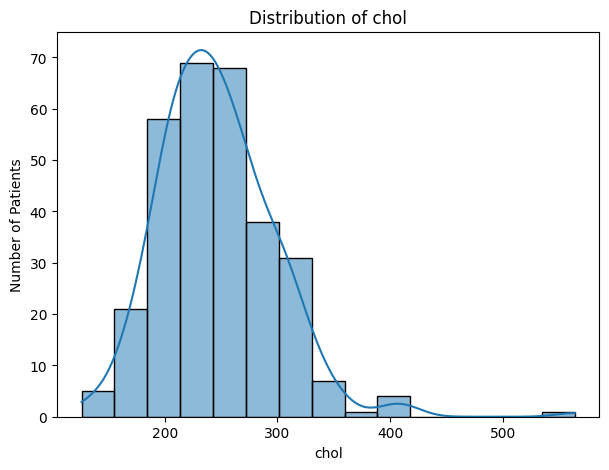

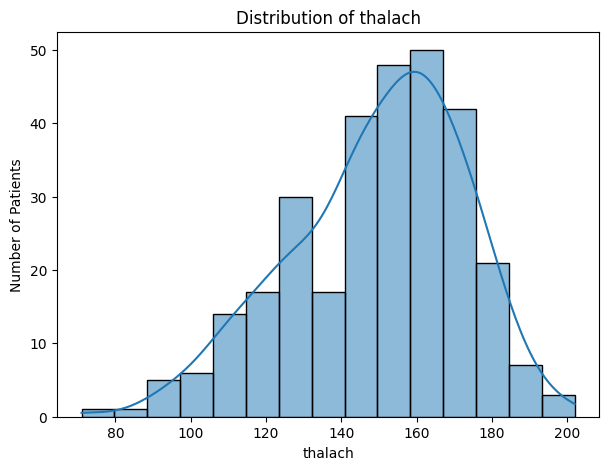

In [13]:
features = ["age", "trestbps", "chol", "thalach"]

for feature in features:
    plt.figure(figsize=(7, 5))

    sns.histplot(
        df[feature],
        bins=15,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Patients")

    plt.show()

#Outlier Inspection

Outlier inspection is performed to identify unusually high or low observations in selected numerical clinical variables.

Boxplots are used to visualize the central distribution, variability, and potential extreme observations for age, resting blood pressure, cholesterol, and maximum heart rate.

The presence of an outlier does not automatically indicate an error. Therefore, the observations will be inspected rather than removed automatically. This approach helps avoid unnecessarily discarding potentially meaningful clinical observations.

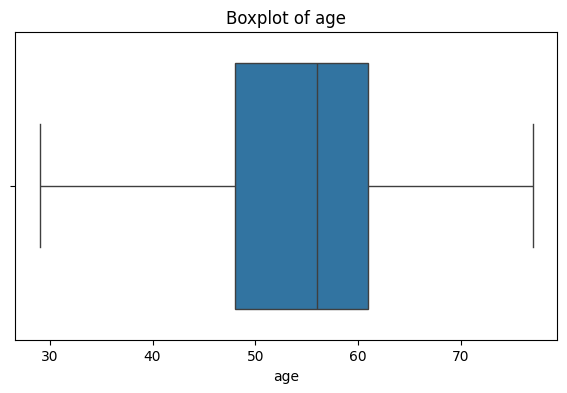

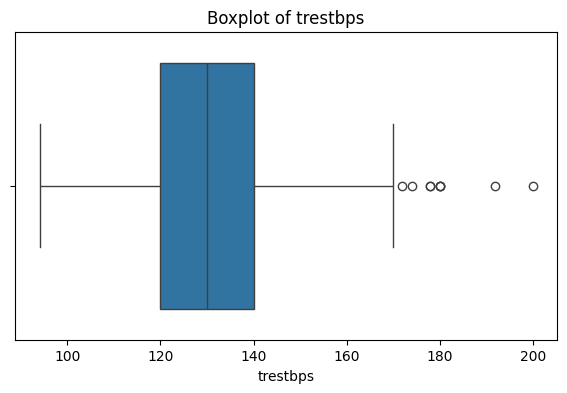

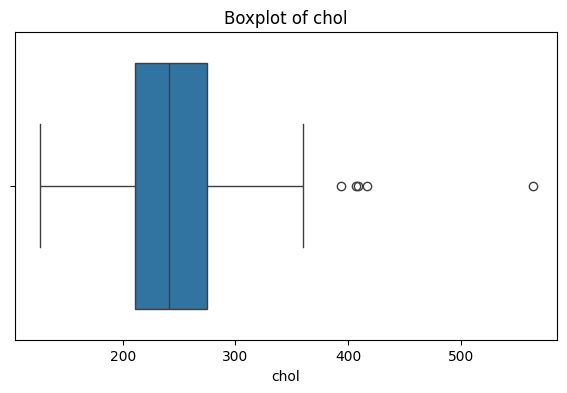

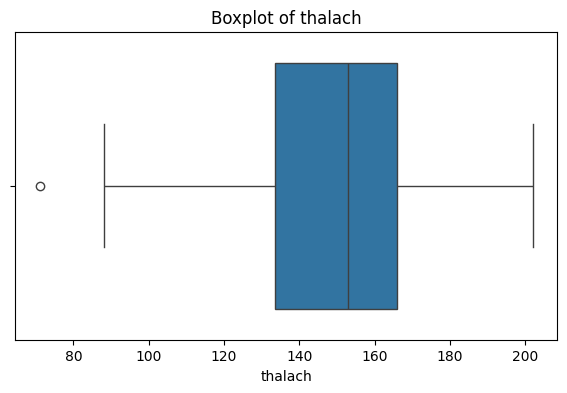

In [14]:
features = ["age", "trestbps", "chol", "thalach"]

for feature in features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(x=df[feature])

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.show()

#Target Transformation

The original UCI Heart Disease dataset represents the target using five categories, where 0 indicates the absence of heart disease and values from 1 to 4 indicate different levels of disease presence.

For this study, the target is transformed into a binary classification variable. The original value 0 is mapped to 0, representing no heart disease, while values 1, 2, 3, and 4 are mapped to 1, representing the presence of heart disease.

This transformation simplifies the prediction task into a binary classification problem while preserving the distinction between patients with and without heart disease.

In [15]:
# Convert the original target into a binary classification target

df["target_binary"] = (df["target"] > 0).astype(int)

print("Original target distribution:")
print(df["target"].value_counts().sort_index())

print("\nBinary target distribution:")
print(df["target_binary"].value_counts().sort_index())

Original target distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target distribution:
target_binary
0    164
1    139
Name: count, dtype: int64


#Feature and Target Preparation

After transforming the original target into a binary classification variable, the dataset is divided into input features and the prediction target.

The original `target` column is excluded from the input features because it contains the original disease outcome and would introduce target leakage if used during model training.

The newly created `target_binary` variable is used as the target, where 0 represents no heart disease and 1 represents the presence of heart disease.

The remaining clinical and demographic variables are used as predictive features.

In [16]:
# Define input features
X = df.drop(columns=["target", "target_binary"])

# Define binary target
y = df["target_binary"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (303, 13)
Target shape: (303,)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target distribution:
target_binary
0    164
1    139
Name: count, dtype: int64


# Train-Test Split

The prepared dataset is divided into training and testing subsets before developing the machine learning models.

An 80:20 split is used, where 80% of the observations are used for model training and 20% are reserved for independent evaluation.

Stratified sampling is applied using the binary target variable to maintain a similar proportion of patients with and without heart disease in both the training and testing datasets.

A fixed random state is used to ensure that the experiment is reproducible.

In [17]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting set:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set:
X_train shape: (242, 13)
y_train shape: (242,)

Testing set:
X_test shape: (61, 13)
y_test shape: (61,)

Training target distribution:
target_binary
0    131
1    111
Name: count, dtype: int64

Testing target distribution:
target_binary
0    33
1    28
Name: count, dtype: int64


# Feature Scaling

Feature scaling is performed to bring the numerical input variables to a comparable scale.

The dataset contains clinical variables with substantially different ranges, such as age, cholesterol, resting blood pressure, and maximum heart rate. Standardization transforms the features so that they have approximately zero mean and unit variance.

The scaler is fitted only on the training data to prevent information from the test set from influencing the preprocessing stage. The same transformation is then applied to the test data.

Feature scaling is particularly important for distance-based and gradient-based algorithms such as Logistic Regression and Support Vector Machine.

In [18]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit only on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Feature scaling completed successfully!
X_train_scaled shape: (242, 13)
X_test_scaled shape: (61, 13)


# Machine Learning Model Development

Four supervised machine learning classification algorithms are developed to predict the binary heart disease target.

The selected models include Logistic Regression, Decision Tree, Random Forest, and XGBoost. These models represent different learning approaches and provide a basis for comparing predictive performance.

The models are trained using the training dataset and their predictions will subsequently be evaluated on the unseen testing dataset.

XGBoost is included as an advanced gradient boosting model and will later be investigated using Explainable Artificial Intelligence techniques.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Create the models

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Train the models

logistic_model.fit(X_train_scaled, y_train)

decision_tree_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

xgb_model.fit(X_train, y_train)

print("All four models trained successfully!")

All four models trained successfully!


# Model Evaluation and Comparison

The trained classification models are evaluated using the independent testing dataset.

Multiple evaluation metrics are used because accuracy alone may not provide a complete picture of classification performance. Precision measures the proportion of predicted positive cases that are actually positive, while recall measures the proportion of actual positive cases correctly identified by the model. The F1-score provides a balance between precision and recall.

ROC-AUC is also calculated to measure the model's ability to distinguish between the two target classes across different classification thresholds.

The performance of Logistic Regression, Decision Tree, Random Forest, and XGBoost is compared using these metrics.

In [20]:
# Generate predictions

pred_logistic = logistic_model.predict(X_test_scaled)
pred_tree = decision_tree_model.predict(X_test)
pred_rf = random_forest_model.predict(X_test)
pred_xgb = xgb_model.predict(X_test)

# Generate prediction probabilities for ROC-AUC

prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]
prob_rf = random_forest_model.predict_proba(X_test)[:, 1]
prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


# Function to calculate evaluation metrics

def evaluate_model(name, y_true, predictions, probabilities):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1-Score": f1_score(y_true, predictions),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }


# Evaluate all models

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        pred_logistic,
        prob_logistic
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        pred_tree,
        prob_tree
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        pred_rf,
        prob_rf
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        pred_xgb,
        prob_xgb
    )
)


# Create comparison DataFrame

results_df = pd.DataFrame(results)

# Display rounded results

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
1,Decision Tree,0.7377,0.6765,0.8214,0.7419,0.7440
2,Random Forest,0.9180,0.8710,0.9643,0.9153,0.9578
3,XGBoost,0.8689,0.7941,0.9643,0.8710,0.9307


#Detailed Evaluation of the Best Model

Based on the comparative evaluation, Random Forest achieved the strongest overall performance among the four classification models.

The model achieved an accuracy of 91.80%, an F1-score of 91.53%, and a ROC-AUC of 95.78% on the testing dataset. Its recall of 96.43% indicates that the model correctly identifies a high proportion of patients belonging to the heart disease class.

A confusion matrix and classification report are used to further examine the classification performance of the selected Random Forest model.

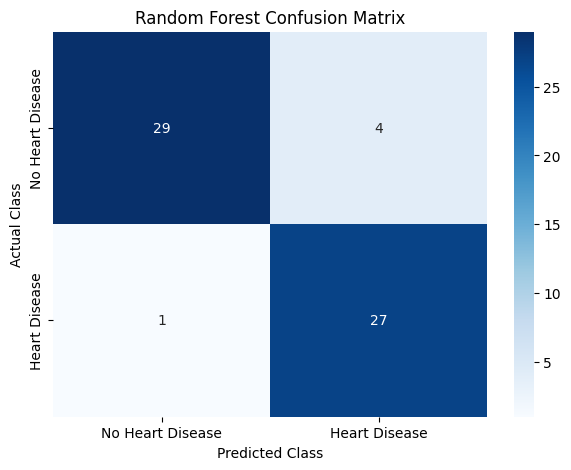

Random Forest Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.97      0.88      0.92        33
   Heart Disease       0.87      0.96      0.92        28

        accuracy                           0.92        61
       macro avg       0.92      0.92      0.92        61
    weighted avg       0.92      0.92      0.92        61



In [21]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()


# Classification Report
print("Random Forest Classification Report:")
print(
    classification_report(
        y_test,
        pred_rf,
        target_names=["No Heart Disease", "Heart Disease"]
    )
)

#Explainable AI with SHAP

Machine learning models can achieve strong predictive performance but may be difficult to interpret. Explainable Artificial Intelligence (XAI) techniques help identify how individual features contribute to model predictions.

SHAP (SHapley Additive exPlanations) is used to interpret the Random Forest model. SHAP assigns an importance value to each feature for individual predictions and helps determine which clinical variables have the greatest influence on the model's output.

A SHAP summary plot will be used to visualize the overall feature importance and the direction and magnitude of feature contributions across the testing dataset.

In [22]:
import shap

# Create SHAP explainer for the trained Random Forest model
explainer = shap.TreeExplainer(random_forest_model)

# Calculate SHAP values for the test dataset
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


#SHAP Summary Plot

The SHAP summary plot provides a global explanation of the Random Forest model. It ranks the input features according to their overall contribution to the model's predictions.

Each point represents an observation from the testing dataset. The horizontal position represents the SHAP value, indicating whether a feature pushes the prediction toward or away from the positive class. The color represents the feature value, with blue indicating lower values and red indicating higher values.

This visualization helps identify the clinical features that have the greatest influence on the model's heart disease predictions.

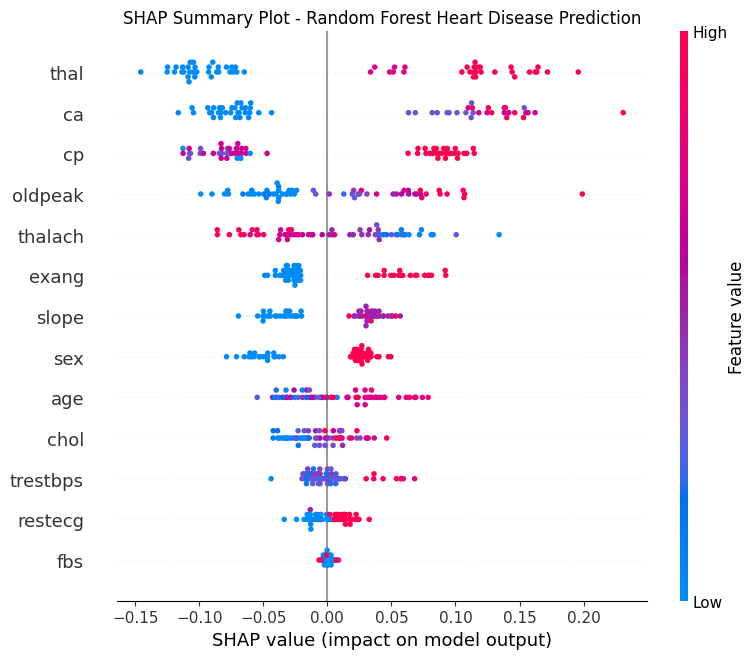

In [23]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    show=False
)

plt.title("SHAP Summary Plot - Random Forest Heart Disease Prediction")

plt.tight_layout()

plt.savefig(
    "shap_summary_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#SHAP Feature Importance

The mean absolute SHAP value is used to calculate the overall importance of each feature in the Random Forest model.

Unlike the SHAP summary plot, which shows the contribution of individual observations, this visualization provides a simplified ranking of the features according to their average impact on the model predictions.

Higher mean absolute SHAP values indicate that a feature has a greater overall influence on the model's predictions.

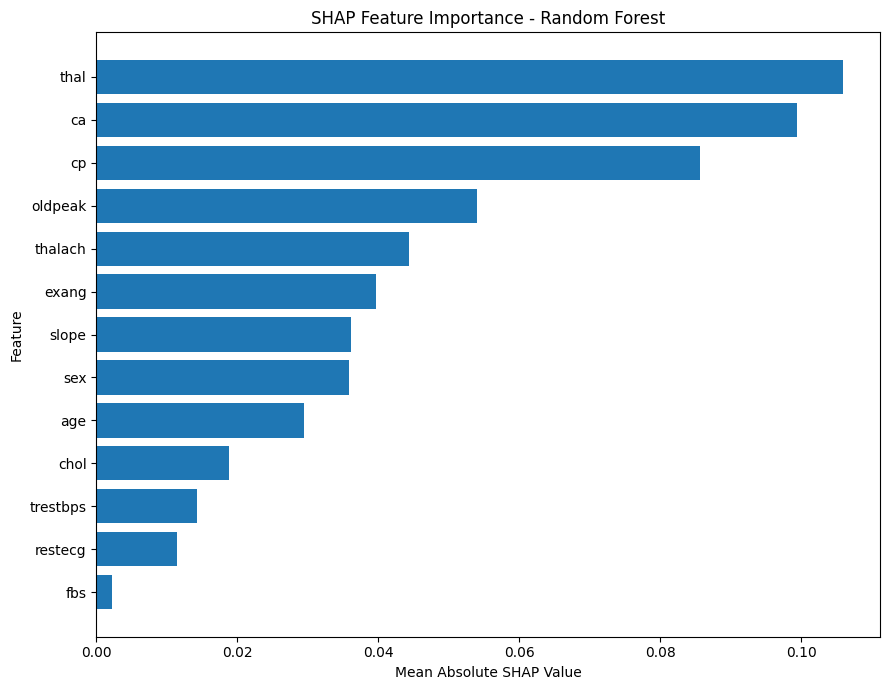

In [24]:
# Calculate mean absolute SHAP values for heart disease class

mean_shap = np.abs(shap_values[:, :, 1]).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Absolute SHAP": mean_shap
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Mean Absolute SHAP",
    ascending=True
)

# Plot feature importance
plt.figure(figsize=(9, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Mean Absolute SHAP"]
)

plt.title("SHAP Feature Importance - Random Forest")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Individual Patient Explanation

Global SHAP analysis explains the overall behavior of the model across the testing dataset. To provide a more detailed explanation, an individual test observation is selected and its prediction is analyzed using SHAP.

The individual explanation shows which clinical features contributed toward or away from the predicted heart disease class for that particular observation.

This demonstrates how Explainable AI can provide case-level interpretability in addition to overall feature importance.

In [25]:
# Select one patient from the test dataset
patient_index = 0

# Create SHAP explanation for the selected patient
patient_shap = shap_values[patient_index, :, 1]

# Create a DataFrame showing feature contributions
patient_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": X_test.iloc[patient_index].values,
    "SHAP Value": patient_shap
})

# Sort by absolute SHAP impact
patient_explanation["Absolute SHAP"] = np.abs(
    patient_explanation["SHAP Value"]
)

patient_explanation = patient_explanation.sort_values(
    by="Absolute SHAP",
    ascending=False
)

print("Individual Patient Explanation")
display(patient_explanation)

Individual Patient Explanation


,Feature,Feature Value,SHAP Value,Absolute SHAP
11,ca,0.0,-0.104532,0.104532
12,thal,3.0,-0.103305,0.103305
0,age,59.0,0.074190,0.074190
7,thalach,182.0,-0.067472,0.067472
2,cp,4.0,0.062965,0.062965
9,oldpeak,0.0,-0.039146,0.039146
8,exang,0.0,-0.023353,0.023353
10,slope,1.0,-0.023137,0.023137
6,restecg,2.0,0.022449,0.022449
1,sex,1.0,0.021992,0.021992


#Individual SHAP Explanation Plot

A SHAP waterfall plot is used to visualize the contribution of individual clinical features to a specific patient's prediction.

The plot shows how the model's base prediction is modified by the feature contributions to arrive at the final model output. Features pushing the prediction toward heart disease and features pushing the prediction away from heart disease can therefore be identified.

This case-level explanation demonstrates how SHAP can make an individual machine learning prediction more interpretable.

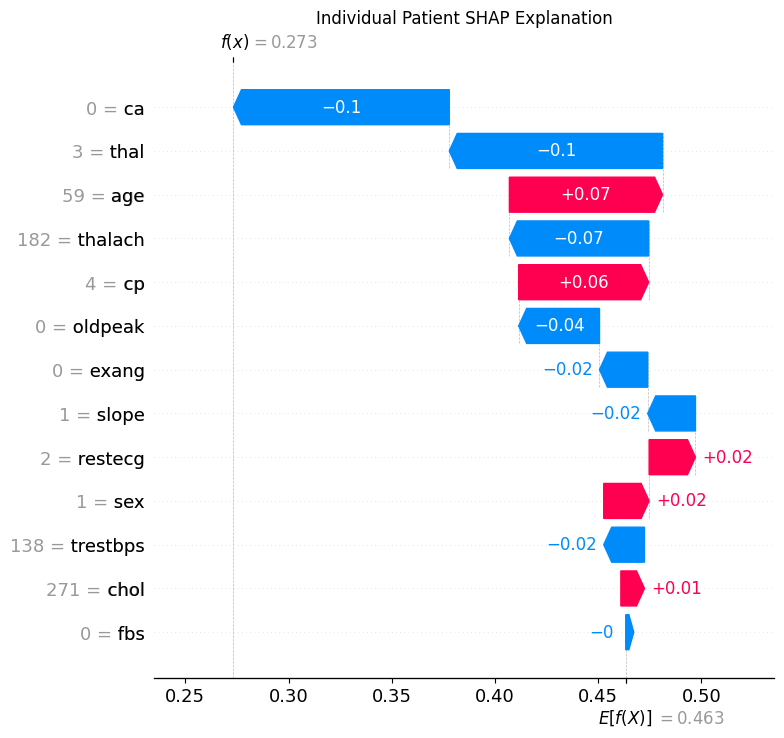

In [26]:
# Create a SHAP Explanation object for the selected patient

patient_explanation_shap = shap.Explanation(
    values=shap_values[patient_index, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[patient_index].values,
    feature_names=X_test.columns
)

# Create the waterfall plot

shap.plots.waterfall(
    patient_explanation_shap,
    max_display=13,
    show=False
)

plt.title("Individual Patient SHAP Explanation")

plt.savefig(
    "individual_patient_shap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Final Model Performance Comparison

The performance of the four developed classification models is compared using accuracy, F1-score, and ROC-AUC.

Visual comparison provides an intuitive representation of the differences in predictive performance between the models. The Random Forest model demonstrated the strongest overall performance on the testing dataset and was therefore selected as the final model for Explainable AI analysis.

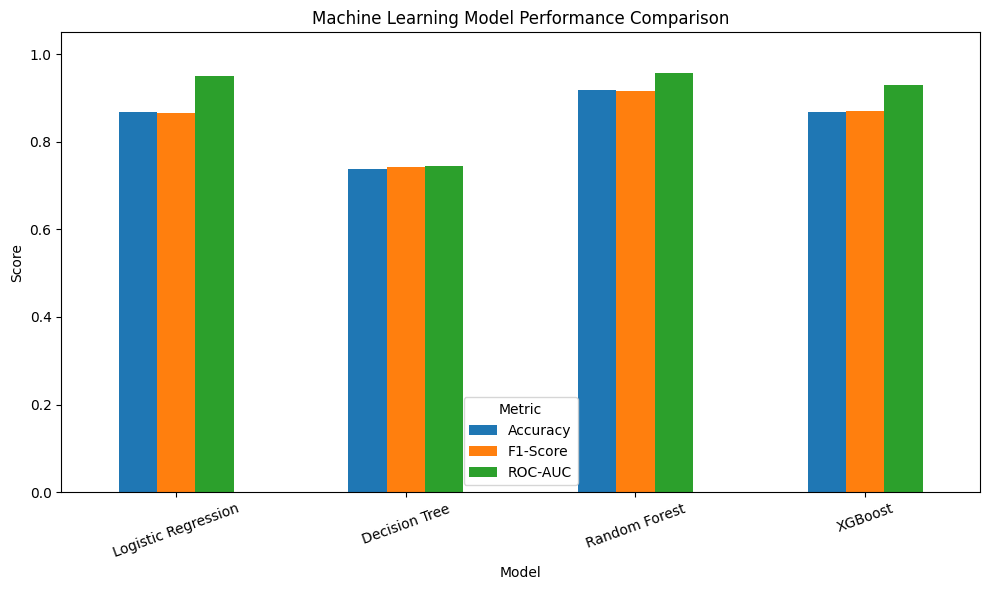

In [27]:
# Prepare data for visualization

comparison_plot = results_df.set_index("Model")[
    ["Accuracy", "F1-Score", "ROC-AUC"]
]

# Create comparison plot

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(title="Metric")

plt.tight_layout()

plt.savefig(
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Final Findings and Conclusion

# Key Findings

The MedExplain-XAI project developed and evaluated four machine learning classification models for heart disease prediction using the Cleveland Heart Disease dataset.

The models evaluated were Logistic Regression, Decision Tree, Random Forest, and XGBoost.

Among the evaluated models, Random Forest achieved the strongest overall performance on the independent testing dataset, with an accuracy of 91.80%, precision of 87.10%, recall of 96.43%, F1-score of 91.53%, and ROC-AUC of 95.78%.

The high recall indicates that the selected model correctly identified a large proportion of observations belonging to the heart disease class.

# Explainable AI Findings

SHAP was used to improve the interpretability of the selected Random Forest model. The SHAP summary analysis provides a global view of how clinical features influence model predictions, while the individual SHAP explanation demonstrates how feature contributions can be examined for a specific patient prediction.

This combination of predictive modeling and explainability makes the project more transparent than a conventional machine learning classification system.

# Conclusion

MedExplain-XAI demonstrates an end-to-end machine learning and Explainable AI workflow for heart disease prediction. The project includes data preprocessing, exploratory analysis, comparative model development, performance evaluation, and SHAP-based interpretation.

The results demonstrate that the Random Forest model provides strong predictive performance on this dataset, while SHAP provides an interpretable view of the factors influencing model predictions.

The project is intended for educational and research purposes and should not be considered a substitute for professional medical diagnosis or clinical decision-making.

# Project Outputs

The following outputs were generated during the MedExplain-XAI analysis:

- Model performance comparison results
- Model performance comparison visualization
- SHAP summary plot
- SHAP feature importance plot
- Individual patient SHAP explanation
- Final model evaluation and classification results

These outputs provide both quantitative evaluation and visual explanations of the developed machine learning models.

In [28]:
# Save the model comparison results

results_df.to_csv(
    "model_results.csv",
    index=False
)

print("Model results saved successfully!")

# Display final results
display(results_df.round(4))

Model results saved successfully!


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
1,Decision Tree,0.7377,0.6765,0.8214,0.7419,0.7440
2,Random Forest,0.9180,0.8710,0.9643,0.9153,0.9578
3,XGBoost,0.8689,0.7941,0.9643,0.8710,0.9307


In [29]:
import os

print("Project files currently available:")

for file in os.listdir():
    if file.endswith((".png", ".csv", ".ipynb")):
        print(file)

Project files currently available:
model_performance_comparison.png
model_results.csv
shap_feature_importance.png
shap_summary_random_forest.png
individual_patient_shap.png
